# Домашнее задание по нейросетям в скоринге.

**ФИО**:

**Данные для обучения**: 
1. [Шардированные данные для нейросети](https://www.kaggle.com/datasets/ahm352/t-intensive-nn-sequence-shards)
2. [Признаки для обучения бустинга](https://www.kaggle.com/datasets/ahm352/t-intensive-features)

**Сдать нужно**: ссылку на Kaggle Notebook. Либо `.ipynb` с outputs ячеек. Воспроизводимость ноута -- большой плюс. Если нейронку обучали на других мощностях (не в kaggle), то можно сохранить модель в kaggle и добавить обученную модель через Input Kaggle для воспроизводимости. 

Если сложности с сохранением модели - нужно прикрепить `.parquet / .csv` с предсказаниями финальной версии модели

За каждый эксперимент по **1.5** балла. Максимум за тип эксперимента **3** балла. Для каждого эксперимента должна быть описана гипотеза и выводы. За невоспроизводимость/сильное переобучение/ без вывода будут штрафы.

Улучшение нейросети будем оценивать в **1** балл за каждое увеличение в **0.0075** auc бейзлайна нейросети. Например, качество улучшилось с `0.69 -> 0.707`. Это оцениваем в **2** балла. Максимум - **4** основных балла (тк качество бустинга **0.72** auc).

За каждое улучшение в **0.01 auc** сверху **0.72 auc** добавляем **1** балл. Максимум **3** балла.

Максимально можно получить **5** дополнительных баллов.

В итоге работы написать отчет с выводами проделанной работы. Интерпретация результатов, краткое описание проделанных экспериментов и идеи для дальнейшего развития этой модели.

## Разбалловка: 20 основных

| Основная часть | Баллы |
|---|---:|
| Воспроизводимость ноута / возможность инференса модели, если обучена не в Kaggle. Run All ячеек на подвыборке отрабатывает | 2 |
| EDA данных. Сформулированы гипотезы, инсайты для дальнейших экспериментов | 1.5 |
| ≥2 эксперимента с данными | 3 |
| ≥2 эксперимента с моделью (архитектурой) | 3 |
| ≥2 эксперимента с loss/обучением | 3 |
| Исследования с артефактами, есть learning curves, логирования в процессе обучения | 1.5 |
| Побито качество (harmonic mean auc) бустинга на тесте | 4 |
| Проинтерпретированы аттрибуты транзакции с помощью permutation importance | 2 |

| **Итого** | **20.00** |

| Бонус | Баллы |
|---|---:|
| Обучена нейросеть с головой для предсказания непрерывного таргета | 3 |
| Качество нейросети на тесте (по harmonic mean auc) с непрерывным таргетом не меньше исходной | 1 |
| Дополнительное улучшение качества нейросети | 3 |
| Пайплайн препроцессинг -> обучение/валидация -> эксперимент. Процесс тестирования экспериментов оформлен в виде шаблонизированного кода | 1.5 |
| Добавлен сервис логирования экспериментов (tensorboard/clearml) | 1 |
| Дополнительные методы интерпретации | 2 |
| **Максимум** | **11.5** |

Критерий **Обучена нейросеть с головой для предсказания непрерывного таргета**:
Необходимо составить самостоятельно таргет - сумму транзакций за последние 30 дней до даты заявки. Его будем считать непрерывным таргетом. Будем предсказывать этот таргет по транзакциям, которые были **до 30 дней** до заявки, чтобы не произвести даталик. 

Далее будет необходимо составить мультитаск нейросеть, которая будет предсказывать и дефолт и сумму транзакций за последние 30 дней.

Лосс, метрики выбираются самостоятельно. Но дополнительно надо измерить harmonic mean auc только по бинарным таргетам.

 `SMOKE_TEST=True` позволяет проверить `Run All` на маленькой подвыборке; для полноценного результата оставить `False`.

In [1]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.utils.data import IterableDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.metrics import roc_auc_score

SEED = 42
SMOKE_TEST = False

MAX_SEQ_LEN = 128
BATCH_SIZE = 256
EXPERIMENT_EPOCHS = 3
FINAL_EPOCHS = 5
SMOKE_TRAIN_PER_PRODUCT = 300
SMOKE_VALID_PER_PRODUCT = 120
SMOKE_EPOCHS = 1
EMBED_DIM = 12
HIDDEN_DIM = 64
DROPOUT = 0.20
BASE_LR = 2e-3
WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0
BOOSTING_THRESHOLD = 0.721359

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PREBUILT_DIR = Path('/kaggle/input/datasets/ahm352/t-intensive-nn-sequence-shards')
BOOSTING_CANDIDATES = [
    Path('/kaggle/input/datasets/ahm352/t-intensive-with-boosting-features/boosting_features.parquet'),
    Path('/kaggle/input/datasets/ahm352/t-intensive-features/boosting_features.parquet'),
    Path('/kaggle/input/t-intensive-features/boosting_features.parquet'),
]
WORK_DIR = Path('/kaggle/working/nn_homework_clean')
RUNS_DIR = WORK_DIR / 'runs'
ARTIFACT_DIR = WORK_DIR / 'artifacts'
for path in (WORK_DIR, RUNS_DIR, ARTIFACT_DIR):
    path.mkdir(parents=True, exist_ok=True)

if not PREBUILT_DIR.exists():
    raise FileNotFoundError(
        'Не найден Dataset t-intensive-nn-sequence-shards. Подключите его как Kaggle Input.'
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = SMOKE_EPOCHS if SMOKE_TEST else EXPERIMENT_EPOCHS
print(f'device={device}; SMOKE_TEST={SMOKE_TEST}; experiment_epochs={EPOCHS}')

device=cuda; SMOKE_TEST=False; experiment_epochs=3


## 1. Data contract и фиксированный split

Sequence producer уже сделал тяжёлый ETL: split, vocabulary, train-only statistics и сохранение ragged NPZ. Мы **не переобучаем preprocessing** на validation/test.

Проверяем, что `app_id`, `product_idx`, target, split и длины sequence согласованы с manifest.

In [2]:
manifest = json.loads((PREBUILT_DIR / 'manifest.json').read_text())
preprocessing = json.loads(
    (PREBUILT_DIR / manifest.get('preprocessing_file', 'preprocessing.json')).read_text()
)
applications = pd.read_parquet(
    PREBUILT_DIR / manifest.get('applications_file', 'applications.parquet')
)

PRODUCTS = list(preprocessing['product_values'])
PRODUCT_TO_IDX = {value: idx for idx, value in enumerate(PRODUCTS)}
STORED_CAT_COLS = list(preprocessing['categorical_columns'])
STORED_CONT_COLS = list(preprocessing['continuous_columns'])
STORED_VOCAB_SIZES = {
    col: int(preprocessing['vocabularies'][col]['size'])
    for col in STORED_CAT_COLS
}

required_columns = {'app_id', 'product', 'product_idx', 'flag', 'split'}
missing = required_columns - set(applications.columns)
if missing:
    raise ValueError(f'applications.parquet: отсутствуют {sorted(missing)}')
if applications['app_id'].duplicated().any():
    raise ValueError('app_id должен быть уникален')
if set(applications['split']) - {'train', 'valid', 'test'}:
    raise ValueError('split должен содержать только train/valid/test')
expected_idx = applications['product'].map(PRODUCT_TO_IDX)
if expected_idx.isna().any() or not np.array_equal(
    expected_idx.to_numpy(), applications['product_idx'].to_numpy()
):
    raise ValueError('product_idx не совпадает с preprocessing mapping')
if int(manifest['max_seq_len']) != MAX_SEQ_LEN:
    raise ValueError('MAX_SEQ_LEN не совпадает с Dataset producer')

print('Products:', PRODUCTS)
print('Categorical:', STORED_CAT_COLS)
print('Continuous:', STORED_CONT_COLS)
print(f'Applications: {len(applications):,}')
display(applications.groupby(['split', 'product', 'flag']).size().rename('n').reset_index())

Products: [0, 1, 2, 3, 4]
Categorical: ['currency', 'operation_kind', 'card_type', 'operation_type', 'operation_type_group', 'ecommerce_flag', 'payment_system', 'income_flag', 'mcc', 'country', 'city', 'mcc_category', 'day_of_week', 'hour', 'weekofyear']
Continuous: ['amnt', 'days_before', 'hour_diff', 'transaction_number']
Applications: 600,000


,split,product,flag,n
0,test,0,0,45863
1,test,0,1,1071
2,test,1,0,23986
3,test,1,1,616
4,test,2,0,6638
5,test,2,1,505
6,test,3,0,5902
7,test,3,1,119
8,test,4,0,5130
9,test,4,1,170


## 2. EDA: где может находиться сигнал?

Фиксируем гипотезы до обучения:

1. **Длина истории:** более длинная история даёт encoder больше контекста.
2. **Время и позиция:** `hour_diff` и `transaction_number` могут сохранять recency и порядок.
3. **Контекст операции:** дополнительные transaction attributes могут различать поведенческие режимы.

Target rate by product and split


,split,product,n,positive,rate
0,test,0,46934,1071,0.022819
1,test,1,24602,616,0.025039
2,test,2,7143,505,0.070699
3,test,3,6021,119,0.019764
4,test,4,5300,170,0.032075
5,train,0,219031,5002,0.022837
6,train,1,114809,2873,0.025024
7,train,2,33330,2354,0.070627
8,train,3,28098,557,0.019823
9,train,4,24732,794,0.032104


count    mean    std  min    25%    50%    75%    max
split product                                                          
test  0         46934.0   97.97  41.87  6.0   63.0  128.0  128.0  128.0
      1         24602.0  104.20  38.86  6.0   86.0  128.0  128.0  128.0
      2          7143.0   86.98  44.88  6.0   43.0  108.0  128.0  128.0
      3          6021.0  109.54  36.24  6.0  122.0  128.0  128.0  128.0
      4          5300.0   86.58  46.11  6.0   40.0  112.0  128.0  128.0
train 0        219031.0   98.11  41.80  6.0   64.0  128.0  128.0  128.0
      1        114809.0  104.38  38.79  6.0   86.0  128.0  128.0  128.0
      2         33330.0   86.36  45.09  6.0   42.0  105.0  128.0  128.0
      3         28098.0  109.42  36.42  6.0  121.0  128.0  128.0  128.0
      4         24732.0   85.72  46.61  6.0   37.0  110.0  128.0  128.0
valid 0         46936.0   98.05  41.78  6.0   63.0  128.0  128.0  128.0
      1         24602.0  104.35  38.84  6.0   86.0  128.0  128.0  128.0
      2          7141.0   85.91  45.25  6.0   41.0  104.0  128.0  128.0
      3          6021.0  109.41  36.37  6.0  120.0  128.0  128.0  128.0
      4          5300.0   84.79  46.81  6.0   36.0  107.0  128.0  128.0

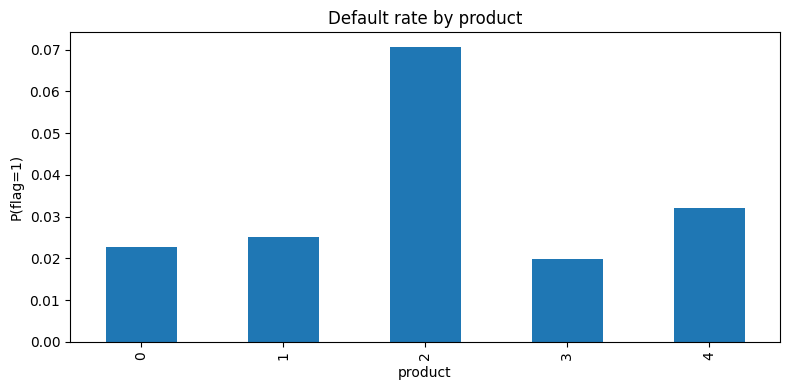

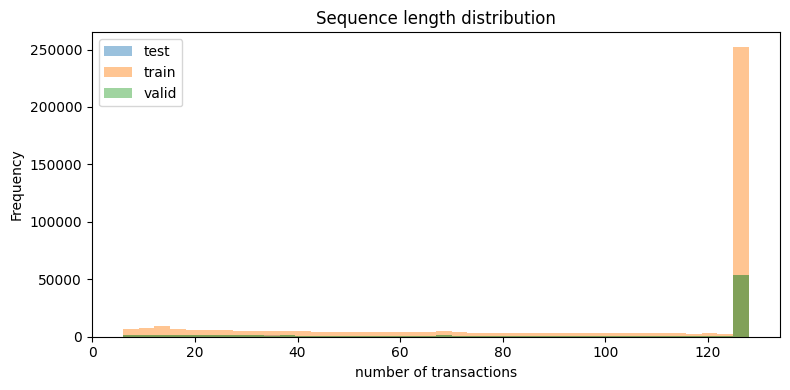

In [3]:
print('Target rate by product and split')
display(
    applications.groupby(['split', 'product'])['flag']
    .agg(n='size', positive='sum', rate='mean')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
applications.groupby('product')['flag'].mean().plot(kind='bar', ax=ax)
ax.set_title('Default rate by product')
ax.set_ylabel('P(flag=1)')
ax.set_xlabel('product')
plt.tight_layout()

REQUIRED_KEYS = {'app_id', 'offsets', 'lengths', 'cats', 'cont', 'target', 'product_idx'}

def shard_paths(split, product_indices=None):
    if split not in manifest['shards']:
        raise ValueError(f'Unknown split={split}')
    groups = manifest['shards'][split]
    keys = sorted(groups, key=int)
    if product_indices is not None:
        keys = [str(index) for index in sorted(product_indices)]
    paths = [PREBUILT_DIR / entry['path'] for key in keys for entry in groups.get(key, [])]
    if not paths:
        raise FileNotFoundError(f'Нет shards для split={split}, products={product_indices}')
    missing_paths = [path for path in paths if not path.is_file()]
    if missing_paths:
        raise FileNotFoundError(f'Не найден shard: {missing_paths[0]}')
    return paths

def sequence_length_table(split):
    frames = []
    for path in shard_paths(split):
        with np.load(path, allow_pickle=False) as archive:
            frames.append(pd.DataFrame({
                'product_idx': archive['product_idx'],
                'length': archive['lengths'],
            }))
    frame = pd.concat(frames, ignore_index=True)
    frame['product'] = frame['product_idx'].map(dict(enumerate(PRODUCTS)))
    frame['split'] = split
    return frame

lengths_df = pd.concat(
    [sequence_length_table(split) for split in ('train', 'valid', 'test')],
    ignore_index=True,
)
display(lengths_df.groupby(['split', 'product'])['length'].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
for split, group in lengths_df.groupby('split'):
    group['length'].clip(upper=MAX_SEQ_LEN).plot(
        kind='hist', bins=40, alpha=0.45, ax=ax, label=split
    )
ax.set_title('Sequence length distribution')
ax.set_xlabel('number of transactions')
ax.legend()
plt.tight_layout()

## 3. Feature sets и гипотезы для data experiments

**Data #1 — temporal context:** добавляем `hour_diff` и `transaction_number`

**Data #2 — all remaining candidates:** добавляем все остальные сохранённые признаки поверх baseline + temporal

Так мы отдельно проверяем идею из семинара: выигрывает ли sequence model, когда ей дают менее агрегированное представление истории

In [4]:
BASE_CAT = [c for c in ['operation_kind', 'mcc', 'income_flag'] if c in STORED_CAT_COLS]
BASE_CONT = [c for c in ['amnt', 'days_before'] if c in STORED_CONT_COLS]
TEMP_CAT = []
TEMP_CONT = [c for c in ['hour_diff', 'transaction_number'] if c in STORED_CONT_COLS]
REMAINING_CAT = [c for c in STORED_CAT_COLS if c not in BASE_CAT + TEMP_CAT]
REMAINING_CONT = [c for c in STORED_CONT_COLS if c not in BASE_CONT + TEMP_CONT]

FEATURE_SETS = {
    'baseline': (BASE_CAT, BASE_CONT),
    'data_temporal': (BASE_CAT + TEMP_CAT, BASE_CONT + TEMP_CONT),
    'data_all_candidates': (
        BASE_CAT + TEMP_CAT + REMAINING_CAT,
        BASE_CONT + TEMP_CONT + REMAINING_CONT,
    ),
}

for name, (cats, conts) in FEATURE_SETS.items():
    print(f'{name}: categorical={cats}; continuous={conts}')
assert BASE_CAT or BASE_CONT

baseline: categorical=['operation_kind', 'mcc', 'income_flag']; continuous=['amnt', 'days_before']
data_temporal: categorical=['operation_kind', 'mcc', 'income_flag']; continuous=['amnt', 'days_before', 'hour_diff', 'transaction_number']
data_all_candidates: categorical=['operation_kind', 'mcc', 'income_flag', 'currency', 'card_type', 'operation_type', 'operation_type_group', 'ecommerce_flag', 'payment_system', 'country', 'city', 'mcc_category', 'day_of_week', 'hour', 'weekofyear']; continuous=['amnt', 'days_before', 'hour_diff', 'transaction_number']


## 4. Ragged NPZ → batch

Каждая заявка хранится в NPZ как последовательность переменной длины. `offsets[i]:offsets[i+1]` задаёт срез истории

Внутри batch вызывается `pad_sequence`, после чего `pack_padded_sequence` использует реальные `length`. Поэтому padding не попадает в hidden state

Для train используем по одному loader на продукт. Один optimizer step объединяет по одному mini-batch каждого продукта

In [5]:
VALIDATED_SHARDS = set()


def validate_shard(data, path):
    missing = REQUIRED_KEYS - set(data)
    if missing:
        raise ValueError(f'{path}: отсутствуют {sorted(missing)}')
    n = len(data['lengths'])
    if any(len(data[name]) != n for name in ('app_id', 'target', 'product_idx')):
        raise ValueError(f'{path}: metadata arrays имеют разную длину')
    if len(data['offsets']) != n + 1 or data['offsets'][0] != 0:
        raise ValueError(f'{path}: некорректные offsets')
    if data['offsets'][-1] != len(data['cats']) or data['offsets'][-1] != len(data['cont']):
        raise ValueError(f'{path}: offsets не совпадают с cats/cont')
    if not np.array_equal(np.diff(data['offsets']), data['lengths']):
        raise ValueError(f'{path}: lengths не совпали с offsets')
    if np.any(data['lengths'] < 1) or np.any(data['lengths'] > MAX_SEQ_LEN):
        raise ValueError(f'{path}: length вне [1, {MAX_SEQ_LEN}]')
    if not np.isfinite(data['cont']).all():
        raise ValueError(f'{path}: cont содержит NaN/inf')
    for idx, col in enumerate(STORED_CAT_COLS):
        ids = data['cats'][:, idx]
        if np.any(ids < 0) or np.any(ids >= STORED_VOCAB_SIZES[col]):
            raise ValueError(f'{path}: categorical ids вне vocabulary {col}')
    if not np.isin(data['target'], [0, 1]).all():
        raise ValueError(f'{path}: target не бинарный')


class NpzSequenceDataset(IterableDataset):
    def __init__(
        self,
        files,
        cat_cols,
        cont_cols,
        shuffle=False,
        seed=SEED,
        max_per_product=None,
        max_total=None,
        required_product=None,
    ):
        self.files = list(files)
        self.cat_cols = list(cat_cols)
        self.cont_cols = list(cont_cols)
        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0
        self.max_per_product = max_per_product
        self.max_total = max_total
        self.required_product = required_product
        self.cat_idx = np.asarray([STORED_CAT_COLS.index(c) for c in self.cat_cols], dtype=int)
        self.cont_idx = np.asarray([STORED_CONT_COLS.index(c) for c in self.cont_cols], dtype=int)

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        files = list(self.files)
        if self.shuffle:
            rng.shuffle(files)
        product_counts = {}
        yielded = 0
        for path in files:
            with np.load(path, allow_pickle=False) as archive:
                data = {key: archive[key] for key in REQUIRED_KEYS}
            if path not in VALIDATED_SHARDS:
                validate_shard(data, path)
                VALIDATED_SHARDS.add(path)
            order = np.arange(len(data['lengths']))
            if self.shuffle:
                rng.shuffle(order)
            for i in order:
                product_idx = int(data['product_idx'][i])
                if self.required_product is not None and product_idx != self.required_product:
                    continue
                if self.max_per_product is not None and product_counts.get(product_idx, 0) >= self.max_per_product:
                    continue
                if self.max_total is not None and yielded >= self.max_total:
                    self.epoch += 1
                    return
                start, stop = data['offsets'][i:i + 2]
                cats = data['cats'][start:stop][:, self.cat_idx]
                cont = data['cont'][start:stop][:, self.cont_idx]
                product_counts[product_idx] = product_counts.get(product_idx, 0) + 1
                yielded += 1
                yield (
                    torch.from_numpy(cats).long(),
                    torch.from_numpy(cont).float(),
                    int(data['lengths'][i]),
                    float(data['target'][i]),
                    product_idx,
                    int(data['app_id'][i]),
                )
        self.epoch += 1


def collate(batch):
    cats, cont, lengths, target, product, app_id = zip(*batch)
    return {
        'cats': pad_sequence(cats, batch_first=True),
        'cont': pad_sequence(cont, batch_first=True),
        'length': torch.tensor(lengths, dtype=torch.long),
        'target': torch.tensor(target, dtype=torch.float32),
        'product': torch.tensor(product, dtype=torch.long),
        'app_id': torch.tensor(app_id, dtype=torch.long),
    }


def make_eval_loader(split, feature_set):
    cats, cont = FEATURE_SETS[feature_set]
    max_per_product = SMOKE_VALID_PER_PRODUCT if SMOKE_TEST else None
    dataset = NpzSequenceDataset(
        shard_paths(split), cats, cont, shuffle=False,
        max_per_product=max_per_product,
    )
    return DataLoader(
        dataset, batch_size=BATCH_SIZE, collate_fn=collate,
        num_workers=0, pin_memory=(device.type == 'cuda'),
    )


def make_product_train_loaders(feature_set):
    cats, cont = FEATURE_SETS[feature_set]
    product_batch_size = max(1, BATCH_SIZE // len(PRODUCTS))
    loaders = {}
    counts = {}
    for product_idx in range(len(PRODUCTS)):
        dataset = NpzSequenceDataset(
            shard_paths('train', {product_idx}),
            cats, cont, shuffle=True, seed=SEED + product_idx,
            max_per_product=SMOKE_TRAIN_PER_PRODUCT if SMOKE_TEST else None,
            required_product=product_idx,
        )
        loaders[product_idx] = DataLoader(
            dataset, batch_size=product_batch_size, collate_fn=collate,
            num_workers=0, pin_memory=(device.type == 'cuda'),
        )
        if SMOKE_TEST:
            counts[product_idx] = SMOKE_TRAIN_PER_PRODUCT
        else:
            counts[product_idx] = sum(
                entry['n_applications']
                for entry in manifest['shards']['train'][str(product_idx)]
            )
    steps = max(math.ceil(counts[p] / product_batch_size) for p in counts)
    return loaders, steps

## 5. Metric и loss

Основная метрика: ROC-AUC отдельно внутри каждого продукта, затем гармоническое среднее.

Для каждого optimizer step сначала усредняем loss внутри каждого продукта, затем складываем продуктовые loss. Значит, frequent product не получает больший вес только из-за размера своей выборки.

Сравниваем: **BCE**, **Focal**, **positive-weighted BCE**.

In [6]:
def harmonic_mean_auc(values):
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or len(values) == 0 or not np.isfinite(values).all():
        raise ValueError('Нужен непустой конечный vector AUC')
    if np.any((values < 0) | (values > 1)):
        raise ValueError('AUC должен быть в [0, 1]')
    return float(len(values) / np.reciprocal(values).sum()) if np.all(values > 0) else 0.0


def product_auc_table(y_true, score, product, expected_products=None):
    y_true, score, product = map(np.asarray, (y_true, score, product))
    if not (len(y_true) == len(score) == len(product)):
        raise ValueError('target, score и product разной длины')
    frame = pd.DataFrame({'target': y_true, 'score': score, 'product': product})
    if expected_products is not None and set(frame['product']) != set(expected_products):
        raise ValueError('Не все ожидаемые products присутствуют')
    rows = []
    for value, group in frame.groupby('product', sort=True):
        if group['target'].nunique() != 2:
            raise ValueError(f'product={value}: нужны оба класса для ROC-AUC')
        rows.append({
            'product': value,
            'n': len(group),
            'positives': int(group['target'].sum()),
            'auc': roc_auc_score(group['target'], group['score']),
        })
    return pd.DataFrame(rows)


def product_harmonic_auc(y_true, score, product, expected_products=None):
    table = product_auc_table(y_true, score, product, expected_products)
    return harmonic_mean_auc(table['auc'].to_numpy()), table


def focal_loss(logits, target, gamma=2.0, alpha=0.5):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, target, reduction='none')
    probability = torch.sigmoid(logits)
    pt = torch.where(target > 0.5, probability, 1.0 - probability)
    alpha_t = torch.where(target > 0.5, alpha, 1.0 - alpha)
    return (alpha_t * (1.0 - pt).pow(gamma) * bce).mean()

stats = applications.groupby(['product_idx', 'flag']).size().unstack(fill_value=0)
POS_WEIGHTS = {
    int(p): float(stats.loc[p, 0] / max(1, stats.loc[p, 1]))
    for p in stats.index
}
print('pos_weight by product:', POS_WEIGHTS)

pos_weight by product: {0: 42.79300209937019, 1: 38.95444579780755, 2: 13.158192090395481, 3: 49.42713567839196, 4: 30.1295154185022}


## 6. Model: shared encoder + product heads

Схема: **categorical embeddings + continuous features → recurrent encoder → hidden representation → product-specific head**.

LSTM и GRU получают одинаковый вход и одинаковый hidden size, а BiLSTM отличается только архитектурой


In [7]:
class MultiHeadSequenceModel(nn.Module):
    def __init__(
        self, cat_cols, cont_cols,
        encoder='lstm', emb_dim=EMBED_DIM, hidden=HIDDEN_DIM,
        layers=1, bidirectional=False, dropout=DROPOUT,
    ):
        super().__init__()
        self.cat_cols = list(cat_cols)
        self.cont_cols = list(cont_cols)
        self.encoder_name = encoder.lower()
        self.bidirectional = bidirectional
        self.embeddings = nn.ModuleList([
            nn.Embedding(STORED_VOCAB_SIZES[col], emb_dim, padding_idx=0)
            for col in self.cat_cols
        ])
        input_width = emb_dim * len(self.cat_cols) + len(self.cont_cols)
        rnn_cls = nn.LSTM if self.encoder_name == 'lstm' else nn.GRU
        rnn_dropout = dropout if layers > 1 else 0.0
        self.rnn = rnn_cls(
            input_width, hidden, num_layers=layers, batch_first=True,
            dropout=rnn_dropout, bidirectional=bidirectional,
        )
        output_width = hidden * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(output_width, 1) for _ in PRODUCTS])

    def forward(self, cats, cont, lengths, product):
        embedded = [embedding(cats[:, :, idx]) for idx, embedding in enumerate(self.embeddings)]
        sequence = torch.cat([*embedded, cont], dim=-1)
        packed = pack_padded_sequence(
            sequence, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        if self.encoder_name == 'lstm':
            _, (hidden, _) = self.rnn(packed)
        else:
            _, hidden = self.rnn(packed)
        if self.bidirectional:
            representation = torch.cat([hidden[-2], hidden[-1]], dim=-1)
        else:
            representation = hidden[-1]
        logits = torch.cat([
            head(self.dropout(representation)) for head in self.heads
        ], dim=1)
        return logits.gather(1, product[:, None]).squeeze(1)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 7. Унифицированный training/evaluation loop

Теперь вся логика обучения находится в одном месте:

`zero_grad → forward → product-balanced loss → backward → gradient clipping → optimizer.step`.

После эпохи: validation H-AUC → scheduler → checkpoint. Для каждой конфигурации также сохраняем CSV и TensorBoard scalars.

In [11]:
@torch.no_grad()
def evaluate(model, loader, expected_products=PRODUCTS):
    model.eval()
    logits_all, targets_all, products_all, ids_all = [], [], [], []
    for batch in loader:
        logits = model(
            batch['cats'].to(device),
            batch['cont'].to(device),
            batch['length'],
            batch['product'].to(device),
        )
        logits_all.append(logits.cpu())
        targets_all.append(batch['target'])
        products_all.append(batch['product'])
        ids_all.append(batch['app_id'])
    logits = torch.cat(logits_all)
    target = torch.cat(targets_all).numpy()
    product_idx = torch.cat(products_all).numpy()
    app_id = torch.cat(ids_all).numpy()
    probability = torch.sigmoid(logits).numpy()
    product = np.asarray(PRODUCTS)[product_idx]
    hauc, table = product_harmonic_auc(target, probability, product, expected_products)
    return hauc, table, target, probability, app_id, product


def product_balanced_loss(logits, target, product, loss_name):
    losses = []
    for p in torch.unique(product, sorted=True):
        mask = product == p
        if loss_name == 'bce':
            value = nn.functional.binary_cross_entropy_with_logits(logits[mask], target[mask])
        elif loss_name == 'focal':
            value = focal_loss(logits[mask], target[mask])
        elif loss_name == 'pos_weighted_bce':
            weight = torch.tensor(POS_WEIGHTS[int(p.item())], device=target.device)
            value = nn.functional.binary_cross_entropy_with_logits(
                logits[mask], target[mask], pos_weight=weight
            )
        else:
            raise ValueError(f'Unknown loss={loss_name}')
        losses.append(value)
    return torch.stack(losses).sum()


def train_one_epoch(model, loaders, steps, optimizer, loss_name):
    model.train()
    iterators = {product_idx: iter(loader) for product_idx, loader in loaders.items()}
    losses = []
    for _ in range(steps):
        optimizer.zero_grad(set_to_none=True)
        logits_parts, target_parts, product_parts = [], [], []
        for product_idx, loader in loaders.items():
            try:
                batch = next(iterators[product_idx])
            except StopIteration:
                iterators[product_idx] = iter(loader)
                batch = next(iterators[product_idx])
            if not batch['product'].eq(product_idx).all():
                raise RuntimeError('Product loader yielded an unexpected product')
            logits_parts.append(model(
                batch['cats'].to(device),
                batch['cont'].to(device),
                batch['length'],
                batch['product'].to(device),
            ))
            target_parts.append(batch['target'].to(device))
            product_parts.append(batch['product'].to(device))
        logits = torch.cat(logits_parts)
        target = torch.cat(target_parts)
        product = torch.cat(product_parts)
        loss = product_balanced_loss(logits, target, product, loss_name)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def train_model(config, feature_set, run_name, epochs=None):
    epochs = EPOCHS if epochs is None else epochs
    cats, cont = FEATURE_SETS[feature_set]
    model = MultiHeadSequenceModel(
        cats, cont,
        encoder=config.get('encoder', 'lstm'),
        hidden=config.get('hidden', HIDDEN_DIM),
        layers=config.get('layers', 1),
        bidirectional=config.get('bidirectional', False),
        dropout=config.get('dropout', DROPOUT),
    ).to(device)

    train_loaders, steps = make_product_train_loaders(feature_set)
    valid_loader = make_eval_loader('valid', feature_set)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('lr', BASE_LR),
        weight_decay=config.get('weight_decay', WEIGHT_DECAY),
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=1, factor=0.5
    )
    writer = SummaryWriter(str(RUNS_DIR / run_name))
    checkpoint = ARTIFACT_DIR / f'{run_name}_best.pt'
    best_hauc = -np.inf
    history = []

    print(f'\n=== {run_name} ===')
    print('feature_set:', feature_set)
    print('config:', config)
    print(f'parameters={count_trainable_parameters(model):,}; steps/epoch={steps}')

    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        train_loss = train_one_epoch(
            model, train_loaders, steps, optimizer,
            config.get('loss', 'bce')
        )
        val_hauc, val_table, *_ = evaluate(model, valid_loader)
        scheduler.step(val_hauc)
        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'val_hmean_auc': val_hauc,
            'lr': optimizer.param_groups[0]['lr'],
            'seconds': time.perf_counter() - started,
        }
        history.append(row)
        writer.add_scalar('train/loss', row['train_loss'], epoch)
        writer.add_scalar('validation/hmean_auc', row['val_hmean_auc'], epoch)
        writer.add_scalar('train/learning_rate', row['lr'], epoch)
        print(
            f"epoch={epoch}/{epochs} | train_loss={row['train_loss']:.5f} | "
            f"val_HAUC={row['val_hmean_auc']:.6f} | seconds={row['seconds']:.1f}"
        )
        if val_hauc > best_hauc:
            best_hauc = val_hauc
            torch.save(model.state_dict(), checkpoint)
            print('  -> best checkpoint saved')

    writer.close()

    # В checkpoint сохранён непосредственно model.state_dict(),
    # поэтому загружаем его без обращения к ключу 'model_state_dict'.
    state = torch.load(
        checkpoint,
        map_location=device,
        weights_only=True,
    )
    model.load_state_dict(state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(ARTIFACT_DIR / f'{run_name}_history.csv', index=False,)
    return model, history_df, checkpoint

## 8. Experiment 0 — baseline

**Гипотеза:** пятипризнаковый LSTM уже может извлечь некоторый сигнал из порядка транзакций


In [12]:
EXPERIMENTS = []
MODELS = {}
HISTORIES = {}
CONFIGS = {}

baseline_config = {
    'encoder': 'lstm', 'hidden': HIDDEN_DIM, 'layers': 1,
    'bidirectional': False, 'loss': 'bce', 'lr': BASE_LR,
}
model, history, checkpoint = train_model(
    baseline_config, 'baseline', 'exp0_baseline'
)
score = float(history['val_hmean_auc'].max())
EXPERIMENTS.append({
    'experiment': 'exp0_baseline', 'family': 'baseline',
    'feature_set': 'baseline', 'best_val_hauc': score,
})
MODELS['exp0_baseline'] = model
HISTORIES['exp0_baseline'] = history
CONFIGS['exp0_baseline'] = baseline_config.copy()
print(f'Baseline best validation H-AUC: {score:.6f}')


=== exp0_baseline ===
feature_set: baseline
config: {'encoder': 'lstm', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'bce', 'lr': 0.002}
parameters=28,437; steps/epoch=4295
epoch=1/3 | train_loss=0.71555 | val_HAUC=0.679733 | seconds=253.3
  -> best checkpoint saved
epoch=2/3 | train_loss=0.68752 | val_HAUC=0.689182 | seconds=249.1
  -> best checkpoint saved
epoch=3/3 | train_loss=0.67652 | val_HAUC=0.689088 | seconds=246.0
Baseline best validation H-AUC: 0.689182


## 9. Data experiments #1 и #2

### Data #1 — temporal context
`hour_diff` + `transaction_number`.

**Гипотеза:** recency и позиция транзакции несут сигнал, который теряется в агрегатах.

### Data #2 — all remaining candidates
Все остальные доступные transaction attributes.

**Гипотеза:** дополнительный контекст поможет как минимум одной product head и, в идеале, общему H-AUC.

Архитектура и loss фиксированы: это ablation именно по входным данным.

In [13]:
for name, feature_set in [
    ('exp1_temporal', 'data_temporal'),
    ('exp2_all_candidates', 'data_all_candidates'),
]:
    model, history, checkpoint = train_model(
        baseline_config, feature_set, name
    )
    score = float(history['val_hmean_auc'].max())
    EXPERIMENTS.append({
        'experiment': name, 'family': 'data',
        'feature_set': feature_set, 'best_val_hauc': score,
    })
    MODELS[name] = model
    HISTORIES[name] = history
    CONFIGS[name] = baseline_config.copy()
    print(f'{name}: best validation H-AUC={score:.6f}')


=== exp1_temporal ===
feature_set: data_temporal
config: {'encoder': 'lstm', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'bce', 'lr': 0.002}
parameters=28,949; steps/epoch=4295
epoch=1/3 | train_loss=0.70812 | val_HAUC=0.711458 | seconds=248.1
  -> best checkpoint saved
epoch=2/3 | train_loss=0.67512 | val_HAUC=0.716945 | seconds=244.4
  -> best checkpoint saved
epoch=3/3 | train_loss=0.66152 | val_HAUC=0.707150 | seconds=245.2
exp1_temporal: best validation H-AUC=0.716945

=== exp2_all_candidates ===
feature_set: data_all_candidates
config: {'encoder': 'lstm', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'bce', 'lr': 0.002}
parameters=72,317; steps/epoch=4295
epoch=1/3 | train_loss=0.69885 | val_HAUC=0.701533 | seconds=321.5
  -> best checkpoint saved
epoch=2/3 | train_loss=0.64659 | val_HAUC=0.697530 | seconds=322.9
epoch=3/3 | train_loss=0.58154 | val_HAUC=0.674330 | seconds=324.1
exp2_all_candidates: best validation H-AUC=0.701533


Добавление всех доступных признаков ухудшило качество относительно temporal-набора
(0.701533 против 0.716945).

Это может означать, что часть дополнительных transaction attributes содержит шум
или усложняет задачу обучения без добавления полезного сигнала, Поэтому увеличение
числа признаков само по себе не гарантирует улучшение sequence-модели.

## 10. Лучшее представление данных для architecture/loss ablation

Выбираем feature set только по результатам baseline + data experiments. Test не участвует.

In [14]:
data_only = pd.DataFrame(EXPERIMENTS)
best_feature_set = data_only.loc[data_only['best_val_hauc'].idxmax(), 'feature_set']
print('Selected feature set for architecture/loss experiments:', best_feature_set)
display(data_only.sort_values('best_val_hauc', ascending=False))

Selected feature set for architecture/loss experiments: data_temporal


,experiment,family,feature_set,best_val_hauc
1,exp1_temporal,data,data_temporal,0.716945
2,exp2_all_candidates,data,data_all_candidates,0.701533
0,exp0_baseline,baseline,baseline,0.689182


## 11. Architecture experiments #1 и #2

**GRU:** гипотеза — более компактный recurrent cell может сохранить качество при меньшей сложности.

**2-layer BiLSTM:** гипотеза — более ёмкий двунаправленный encoder извлечёт больше контекста из сохранённой истории.

Входные данные и BCE фиксированы.

In [15]:
architecture_configs = {
    'exp3_gru': {
        'encoder': 'gru', 'hidden': HIDDEN_DIM, 'layers': 1,
        'bidirectional': False, 'loss': 'bce', 'lr': BASE_LR,
    },
    'exp4_bilstm': {
        'encoder': 'lstm', 'hidden': HIDDEN_DIM, 'layers': 2,
        'bidirectional': True, 'loss': 'bce', 'lr': 1e-3,
    },
}

for name, config in architecture_configs.items():
    model, history, checkpoint = train_model(
        config, best_feature_set, name
    )
    score = float(history['val_hmean_auc'].max())
    EXPERIMENTS.append({
        'experiment': name, 'family': 'architecture',
        'feature_set': best_feature_set, 'best_val_hauc': score,
    })
    MODELS[name] = model
    HISTORIES[name] = history
    CONFIGS[name] = config.copy()
    print(f'{name}: best validation H-AUC={score:.6f}; parameters={count_trainable_parameters(model):,}')


=== exp3_gru ===
feature_set: data_temporal
config: {'encoder': 'gru', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'bce', 'lr': 0.002}
parameters=22,165; steps/epoch=4295
epoch=1/3 | train_loss=0.69618 | val_HAUC=0.709049 | seconds=246.9
  -> best checkpoint saved
epoch=2/3 | train_loss=0.66469 | val_HAUC=0.703619 | seconds=245.1
epoch=3/3 | train_loss=0.62867 | val_HAUC=0.680102 | seconds=244.7
exp3_gru: best validation H-AUC=0.709049; parameters=22,165

=== exp4_bilstm ===
feature_set: data_temporal
config: {'encoder': 'lstm', 'hidden': 64, 'layers': 2, 'bidirectional': True, 'loss': 'bce', 'lr': 0.001}
parameters=155,733; steps/epoch=4295
epoch=1/3 | train_loss=0.70673 | val_HAUC=0.692274 | seconds=485.7
  -> best checkpoint saved
epoch=2/3 | train_loss=0.67217 | val_HAUC=0.705083 | seconds=488.0
  -> best checkpoint saved
epoch=3/3 | train_loss=0.64479 | val_HAUC=0.691412 | seconds=484.2
exp4_bilstm: best validation H-AUC=0.705083; parameters=155,733


## 12. Loss / training experiments #1 и #2

**Focal loss:** сложные примеры получают больший градиентный вес.

**Positive-weighted BCE:** компенсируем дисбаланс positive class внутри каждого продукта.

Encoder и feature set фиксированы к baseline LSTM + лучшему data representation.

In [16]:
loss_configs = {
    'exp5_focal': {
        'encoder': 'lstm', 'hidden': HIDDEN_DIM, 'layers': 1,
        'bidirectional': False, 'loss': 'focal', 'lr': BASE_LR,
    },
    'exp6_posweighted': {
        'encoder': 'lstm', 'hidden': HIDDEN_DIM, 'layers': 1,
        'bidirectional': False, 'loss': 'pos_weighted_bce', 'lr': BASE_LR,
    },
}

for name, config in loss_configs.items():
    model, history, checkpoint = train_model(
        config, best_feature_set, name
    )
    score = float(history['val_hmean_auc'].max())
    EXPERIMENTS.append({
        'experiment': name, 'family': 'loss_training',
        'feature_set': best_feature_set, 'best_val_hauc': score,
    })
    MODELS[name] = model
    HISTORIES[name] = history
    CONFIGS[name] = config.copy()
    print(f'{name}: best validation H-AUC={score:.6f}')


=== exp5_focal ===
feature_set: data_temporal
config: {'encoder': 'lstm', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'focal', 'lr': 0.002}
parameters=28,949; steps/epoch=4295
epoch=1/3 | train_loss=0.10059 | val_HAUC=0.706231 | seconds=257.5
  -> best checkpoint saved
epoch=2/3 | train_loss=0.09547 | val_HAUC=0.709766 | seconds=257.6
  -> best checkpoint saved
epoch=3/3 | train_loss=0.09218 | val_HAUC=0.692391 | seconds=258.3
exp5_focal: best validation H-AUC=0.709766

=== exp6_posweighted ===
feature_set: data_temporal
config: {'encoder': 'lstm', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'pos_weighted_bce', 'lr': 0.002}
parameters=28,949; steps/epoch=4295
epoch=1/3 | train_loss=6.28759 | val_HAUC=0.701212 | seconds=252.8
  -> best checkpoint saved
epoch=2/3 | train_loss=5.90315 | val_HAUC=0.701247 | seconds=252.6
  -> best checkpoint saved
epoch=3/3 | train_loss=5.44317 | val_HAUC=0.675881 | seconds=251.3
exp6_posweighted: best validation H-AUC=0.7012

## 13. Сводка всех экспериментов




In [17]:
results = pd.DataFrame(EXPERIMENTS).sort_values('best_val_hauc', ascending=False).reset_index(drop=True)
baseline_hauc = float(
    results.loc[results['experiment'].eq('exp0_baseline'), 'best_val_hauc'].iloc[0]
)
results['delta_vs_baseline'] = results['best_val_hauc'] - baseline_hauc
results['parameters'] = results['experiment'].map({
    name: count_trainable_parameters(model) for name, model in MODELS.items()
})
display(results)

BEST_EXPERIMENT = results.loc[0, 'experiment']
BEST_FEATURE_SET = results.loc[0, 'feature_set']
BEST_CONFIG = CONFIGS[BEST_EXPERIMENT].copy()
print('BEST_EXPERIMENT =', BEST_EXPERIMENT)
print('BEST_FEATURE_SET =', BEST_FEATURE_SET)
print('BEST_CONFIG =', BEST_CONFIG)

,experiment,family,feature_set,best_val_hauc,delta_vs_baseline,parameters
0,exp1_temporal,data,data_temporal,0.716945,0.027763,28949
1,exp5_focal,loss_training,data_temporal,0.709766,0.020584,28949
2,exp3_gru,architecture,data_temporal,0.709049,0.019867,22165
3,exp4_bilstm,architecture,data_temporal,0.705083,0.015901,155733
4,exp2_all_candidates,data,data_all_candidates,0.701533,0.012351,72317
5,exp6_posweighted,loss_training,data_temporal,0.701247,0.012065,28949
6,exp0_baseline,baseline,baseline,0.689182,0.000000,28437


BEST_EXPERIMENT = exp1_temporal
BEST_FEATURE_SET = data_temporal
BEST_CONFIG = {'encoder': 'lstm', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'bce', 'lr': 0.002}


## 14. Learning curves и TensorBoard

Каждый эксперимент сохраняет историю epoch → train loss / validation H-AUC / learning rate / wall-clock time. Это позволяет увидеть переобучение и стоимость эксперимента.

History CSV files:
  exp0_baseline_history.csv
  exp1_temporal_history.csv
  exp2_all_candidates_history.csv
  exp3_gru_history.csv
  exp4_bilstm_history.csv
  exp5_focal_history.csv
  exp6_posweighted_history.csv
TensorBoard runs: ['exp0_baseline', 'exp1_temporal', 'exp2_all_candidates', 'exp3_gru', 'exp4_bilstm', 'exp5_focal', 'exp6_posweighted']


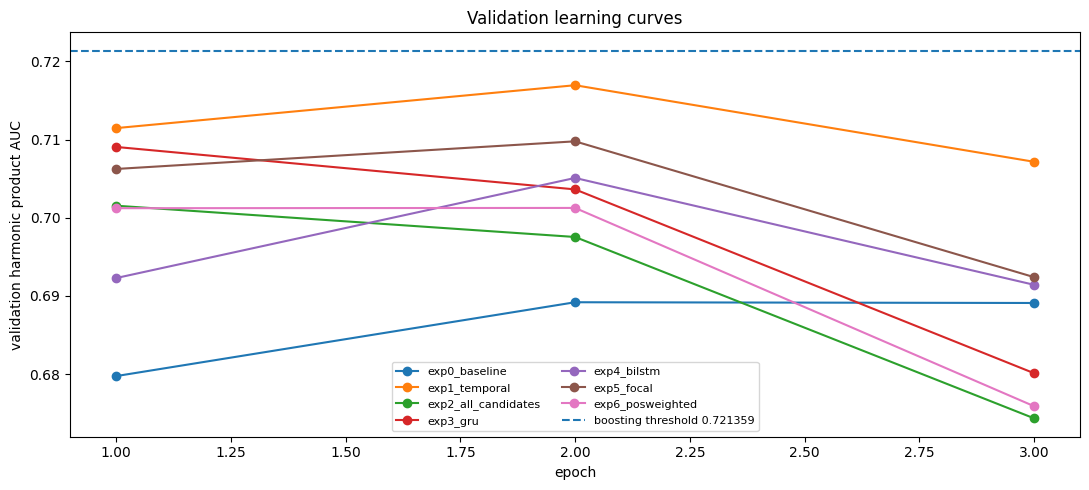

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, history in HISTORIES.items():
    ax.plot(history['epoch'], history['val_hmean_auc'], marker='o', label=name)
ax.axhline(BOOSTING_THRESHOLD, linestyle='--', label='boosting threshold 0.721359')
ax.set_xlabel('epoch')
ax.set_ylabel('validation harmonic product AUC')
ax.set_title('Validation learning curves')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

print('History CSV files:')
for path in sorted(ARTIFACT_DIR.glob('*_history.csv')):
    print(' ', path.name)
print('TensorBoard runs:', sorted(path.name for path in RUNS_DIR.iterdir() if path.is_dir()))

## 15. Permutation importance атрибутов транзакции

Для sequence data стандартный flat-table `sklearn.permutation_importance` не показывает, что происходит внутри истории. Поэтому переставляем **целый столбец признака между заявками внутри batch**. Внутренний порядок каждой истории при этом сохраняется.

Падение H-AUC после permutation — наш measure of importance.

,feature,kind,baseline_hauc,permuted_hauc,drop
0,hour_diff,continuous,0.716945,0.619078,0.097867
1,mcc,categorical,0.716945,0.634803,0.082142
2,operation_kind,categorical,0.716945,0.678113,0.038831
3,amnt,continuous,0.716945,0.699353,0.017591
4,transaction_number,continuous,0.716945,0.703266,0.013679
5,income_flag,categorical,0.716945,0.708480,0.008465
6,days_before,continuous,0.716945,0.709798,0.007146


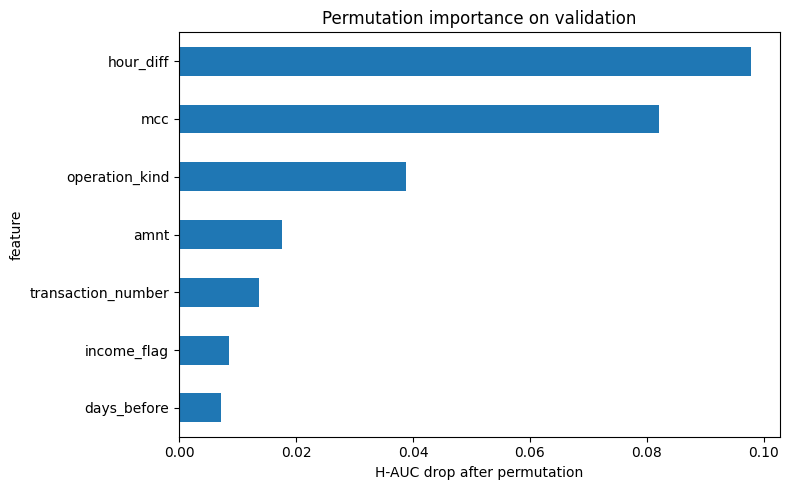

In [19]:
@torch.no_grad()
def evaluate_with_permutation(model, loader, kind=None, feature_index=None, seed=SEED):
    model.eval()
    rng = np.random.default_rng(seed)
    targets, scores, products = [], [], []
    for batch in loader:
        cats = batch['cats'].clone()
        cont = batch['cont'].clone()
        if kind is not None:
            permutation = torch.as_tensor(rng.permutation(len(batch['target'])), dtype=torch.long)
            if kind == 'cat':
                cats[:, :, feature_index] = cats[permutation, :, feature_index]
            else:
                cont[:, :, feature_index] = cont[permutation, :, feature_index]
        logits = model(
            cats.to(device), cont.to(device),
            batch['length'], batch['product'].to(device)
        )
        targets.append(batch['target'].numpy())
        scores.append(torch.sigmoid(logits).cpu().numpy())
        products.append(np.asarray(PRODUCTS)[batch['product'].numpy()])
    y = np.concatenate(targets)
    s = np.concatenate(scores)
    p = np.concatenate(products)
    return product_harmonic_auc(y, s, p, PRODUCTS)[0]

best_validation_model = MODELS[BEST_EXPERIMENT]
validation_loader = make_eval_loader('valid', BEST_FEATURE_SET)
base_importance_auc = evaluate_with_permutation(best_validation_model, validation_loader)
cat_cols, cont_cols = FEATURE_SETS[BEST_FEATURE_SET]
importance_rows = []
for index, name in enumerate(cat_cols):
    score = evaluate_with_permutation(best_validation_model, validation_loader, 'cat', index, SEED + index)
    importance_rows.append({
        'feature': name, 'kind': 'categorical',
        'baseline_hauc': base_importance_auc,
        'permuted_hauc': score,
        'drop': base_importance_auc - score,
    })
for index, name in enumerate(cont_cols):
    score = evaluate_with_permutation(best_validation_model, validation_loader, 'cont', index, SEED + 100 + index)
    importance_rows.append({
        'feature': name, 'kind': 'continuous',
        'baseline_hauc': base_importance_auc,
        'permuted_hauc': score,
        'drop': base_importance_auc - score,
    })

permutation_df = pd.DataFrame(importance_rows).sort_values('drop', ascending=False).reset_index(drop=True)
permutation_df.to_csv(ARTIFACT_DIR / 'permutation_importance_validation.csv', index=False)
display(permutation_df)

fig, ax = plt.subplots(figsize=(8, 5))
permutation_df.sort_values('drop').plot.barh(
    x='feature', y='drop', ax=ax, legend=False
)
ax.set_xlabel('H-AUC drop after permutation')
ax.set_title('Permutation importance on validation')
plt.tight_layout()

## 16. Финальная модель

Выбрана конфигурация по validation. Теперь запускаем отдельное финальное обучение на полном train, снова выбирая лучшую эпоху по validation H-AUC. До этого момента test не открывался.

In [20]:
final_model, final_history, final_checkpoint = train_model(
    BEST_CONFIG,
    BEST_FEATURE_SET,
    'final_model',
    epochs=(SMOKE_EPOCHS if SMOKE_TEST else FINAL_EPOCHS),
)
final_val_hauc = float(final_history['val_hmean_auc'].max())
print(f'Final validation best H-AUC: {final_val_hauc:.6f}')


=== final_model ===
feature_set: data_temporal
config: {'encoder': 'lstm', 'hidden': 64, 'layers': 1, 'bidirectional': False, 'loss': 'bce', 'lr': 0.002}
parameters=28,949; steps/epoch=4295
epoch=1/5 | train_loss=0.70984 | val_HAUC=0.707053 | seconds=250.7
  -> best checkpoint saved
epoch=2/5 | train_loss=0.67554 | val_HAUC=0.710438 | seconds=250.6
  -> best checkpoint saved
epoch=3/5 | train_loss=0.66220 | val_HAUC=0.701740 | seconds=250.1
epoch=4/5 | train_loss=0.64646 | val_HAUC=0.691154 | seconds=249.1
epoch=5/5 | train_loss=0.61480 | val_HAUC=0.680561 | seconds=249.7
Final validation best H-AUC: 0.710438


## 17. Финальный test и сравнение с CatBoost

Теперь открываем test. Для CatBoost дополнительно проверяем совпадение application cohort по `app_id`, `product`, `flag`, `split`, чтобы не получить сравнение разных выборок.

In [21]:
test_loader = make_eval_loader('test', BEST_FEATURE_SET)
lstm_test_hauc, lstm_product_table, lstm_y, lstm_prob, lstm_ids, lstm_product = evaluate(
    final_model, test_loader, PRODUCTS
)
print(f'FINAL LSTM test harmonic product AUC: {lstm_test_hauc:.6f}')
display(lstm_product_table)

boosting_path = next((path for path in BOOSTING_CANDIDATES if path.is_file()), None)
if boosting_path is None:
    raise FileNotFoundError(
        'Не найден boosting_features.parquet. Подключите boosting dataset из семинара.'
    )

features = pd.read_parquet(boosting_path)
required_boost_columns = {'app_id', 'product', 'flag', 'split'}
missing_boost = required_boost_columns - set(features.columns)
if missing_boost:
    raise ValueError(f'В boosting features отсутствуют {sorted(missing_boost)}')

reference = applications.set_index('app_id')[['product', 'flag', 'split']]
observed = features.set_index('app_id')[['product', 'flag', 'split']]
if set(reference.index) != set(observed.index):
    raise ValueError('CatBoost и LSTM используют разные app_id')
reference = reference.sort_index()
observed = observed.sort_index()
if not (reference == observed).all().all():
    raise ValueError('product/flag/split не совпадают между boosting features и sequence applications')

X = features.drop(columns=['app_id', 'flag', 'split']).copy()
X.columns = X.columns.astype(str)
cat_names = {'product'}
cat_names.update(col for col in X.columns if col.startswith('MODE('))
cat_names.update(X.select_dtypes(include=['object', 'category', 'string']).columns)
for col in cat_names:
    X[col] = X[col].astype('string').fillna('__NA__').astype(str)
X = X.replace([np.inf, -np.inf], np.nan)
cat_indices = [X.columns.get_loc(col) for col in sorted(cat_names)]

from catboost import CatBoostClassifier
catboost = CatBoostClassifier(
    iterations=700,
    depth=4,
    learning_rate=0.13711265130376526,
    l2_leaf_reg=7.087424304645033,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False,
    allow_writing_files=False,
)
train_mask = features['split'].eq('train')
test_mask = features['split'].eq('test')
catboost.fit(
    X.loc[train_mask],
    features.loc[train_mask, 'flag'].astype(int),
    cat_features=cat_indices,
)
cat_prob = catboost.predict_proba(X.loc[test_mask])[:, 1]
cat_hauc, cat_product_table = product_harmonic_auc(
    features.loc[test_mask, 'flag'].to_numpy(),
    cat_prob,
    features.loc[test_mask, 'product'].to_numpy(),
    PRODUCTS,
)
print(f'CatBoost test harmonic product AUC: {cat_hauc:.6f}')
display(cat_product_table)

comparison = pd.DataFrame({
    'model': ['CatBoost', 'Final LSTM'],
    'test_harmonic_auc': [cat_hauc, lstm_test_hauc],
    'beats_0.721359': [cat_hauc > BOOSTING_THRESHOLD, lstm_test_hauc > BOOSTING_THRESHOLD],
    'lstm_beats_catboost': [False, lstm_test_hauc > cat_hauc],
})
display(comparison)

FINAL LSTM test harmonic product AUC: 0.706339


,product,n,positives,auc
0,0,46934,1071,0.745343
1,1,24602,616,0.717489
2,2,7143,505,0.743632
3,3,6021,119,0.714687
4,4,5300,170,0.625244


CatBoost test harmonic product AUC: 0.721359


,product,n,positives,auc
0,0,46934,1071,0.758860
1,1,24602,616,0.731645
2,2,7143,505,0.740987
3,3,6021,119,0.743001
4,4,5300,170,0.644592


,model,test_harmonic_auc,beats_0.721359,lstm_beats_catboost
0,CatBoost,0.721359,False,False
1,Final LSTM,0.706339,False,False


Лучший вариант нейросети выбирается только по validation H-AUC.
На независимом test получаем:

- CatBoost: **0.721359**
- Final LSTM: **0.706339**

Таким образом, основную цель ДЗ — превзойти CatBoost по harmonic mean AUC на test —
в текущем эксперименте выполнить не удалось.

При этом sequence-подход дал заметный прирост относительно baseline LSTM:
с **0.689182** до лучшего validation значения **0.716945** (+0.027763).

## 18. Финальные артефакты


In [22]:
final_predictions = pd.DataFrame({
    'app_id': lstm_ids,
    'product': lstm_product,
    'target': lstm_y,
    'probability': lstm_prob,
})
final_predictions.to_csv(ARTIFACT_DIR / 'final_test_predictions.csv', index=False)
final_predictions.to_parquet(ARTIFACT_DIR / 'final_test_predictions.parquet', index=False)

final_config = {
    'seed': SEED,
    'feature_set': BEST_FEATURE_SET,
    'categorical_columns': FEATURE_SETS[BEST_FEATURE_SET][0],
    'continuous_columns': FEATURE_SETS[BEST_FEATURE_SET][1],
    'config': BEST_CONFIG,
    'max_seq_len': MAX_SEQ_LEN,
    'metric': 'harmonic mean of product ROC-AUC',
    'boosting_threshold': BOOSTING_THRESHOLD,
    'checkpoint': str(final_checkpoint),
}
(ARTIFACT_DIR / 'final_config.json').write_text(
    json.dumps(final_config, ensure_ascii=False, indent=2)
)

print('Artifacts:')
for path in sorted(ARTIFACT_DIR.iterdir()):
    print(' ', path.name)

Artifacts:
  exp0_baseline_best.pt
  exp0_baseline_history.csv
  exp1_temporal_best.pt
  exp1_temporal_history.csv
  exp2_all_candidates_best.pt
  exp2_all_candidates_history.csv
  exp3_gru_best.pt
  exp3_gru_history.csv
  exp4_bilstm_best.pt
  exp4_bilstm_history.csv
  exp5_focal_best.pt
  exp5_focal_history.csv
  exp6_posweighted_best.pt
  exp6_posweighted_history.csv
  final_config.json
  final_model_best.pt
  final_model_history.csv
  final_test_predictions.csv
  final_test_predictions.parquet
  permutation_importance_validation.csv


## 19. Итоговый отчёт


In [23]:
print('### Отчёт по домашнему заданию')
print()
print(f'- Baseline validation H-AUC: {baseline_hauc:.6f}')
print(f'- Best validation experiment: {BEST_EXPERIMENT}')
print(f'- Best validation H-AUC: {float(results.iloc[0]['best_val_hauc']):.6f}')
print(f'- Final validation H-AUC: {final_val_hauc:.6f}')
print(f'- Final LSTM test H-AUC: {lstm_test_hauc:.6f}')
print(f'- CatBoost test H-AUC: {cat_hauc:.6f}')
print(f'- Beats 0.721359: {'YES' if lstm_test_hauc > BOOSTING_THRESHOLD else 'NO'}')
print()
print('### Интерпретация экспериментов')
for _, row in results.iterrows():
    direction = 'улучшение' if row['delta_vs_baseline'] > 0 else 'ухудшение/без прироста'
    print(
        f"- {row['experiment']} ({row['family']}): H-AUC={row['best_val_hauc']:.6f}; "
        f"delta={row['delta_vs_baseline']:+.6f} — {direction}."
    )
print()
print('### Что проверить перед сдачей')
print('- learning curves: нет ли сильного train/validation divergence;')
print('- permutation importance: какие атрибуты реально двигают validation H-AUC;')
print('- final test: отдельный ли это cohort и действительно ли LSTM выше 0.721359;')
print('- artifacts: checkpoint + final_test_predictions.csv/parquet сохранены.')

display(results[['experiment', 'family', 'feature_set', 'best_val_hauc', 'delta_vs_baseline', 'parameters']])
display(comparison)

### Отчёт по домашнему заданию

- Baseline validation H-AUC: 0.689182
- Best validation experiment: exp1_temporal
- Best validation H-AUC: 0.716945
- Final validation H-AUC: 0.710438
- Final LSTM test H-AUC: 0.706339
- CatBoost test H-AUC: 0.721359
- Beats 0.721359: NO

### Интерпретация экспериментов
- exp1_temporal (data): H-AUC=0.716945; delta=+0.027763 — улучшение.
- exp5_focal (loss_training): H-AUC=0.709766; delta=+0.020584 — улучшение.
- exp3_gru (architecture): H-AUC=0.709049; delta=+0.019867 — улучшение.
- exp4_bilstm (architecture): H-AUC=0.705083; delta=+0.015901 — улучшение.
- exp2_all_candidates (data): H-AUC=0.701533; delta=+0.012351 — улучшение.
- exp6_posweighted (loss_training): H-AUC=0.701247; delta=+0.012065 — улучшение.
- exp0_baseline (baseline): H-AUC=0.689182; delta=+0.000000 — ухудшение/без прироста.

### Что проверить перед сдачей
- learning curves: нет ли сильного train/validation divergence;
- permutation importance: какие атрибуты реально двигают validation 

,experiment,family,feature_set,best_val_hauc,delta_vs_baseline,parameters
0,exp1_temporal,data,data_temporal,0.716945,0.027763,28949
1,exp5_focal,loss_training,data_temporal,0.709766,0.020584,28949
2,exp3_gru,architecture,data_temporal,0.709049,0.019867,22165
3,exp4_bilstm,architecture,data_temporal,0.705083,0.015901,155733
4,exp2_all_candidates,data,data_all_candidates,0.701533,0.012351,72317
5,exp6_posweighted,loss_training,data_temporal,0.701247,0.012065,28949
6,exp0_baseline,baseline,baseline,0.689182,0.000000,28437


,model,test_harmonic_auc,beats_0.721359,lstm_beats_catboost
0,CatBoost,0.721359,False,False
1,Final LSTM,0.706339,False,False
